# IDC Baseline Training With PyTorch

This notebook runs the first supervised baseline model for patch-level IDC classification.

Workflow:
- mount Google Drive
- reuse the cached dataset zip from Drive
- extract the dataset into `/content`
- read the cleaned train/val/test split CSVs from `artifacts/`
- train a baseline CNN with class-weighted loss
- save the best checkpoint, history, and metrics


In [1]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# Notebook 03 trains the first custom CNN baseline from scratch.
PROJECT_ROOT = Path('/content/drive/MyDrive/Workshop UDL')
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_ARCHIVE_PATH = PROJECT_ROOT / 'datasets' / 'Breast Cancer Histopathology Dataset.zip'
TRAINING_RUNS_DIR = PROJECT_ROOT / 'training_runs'

RUNTIME_DIR = Path('/content/idc_runtime')
RUNTIME_EXTRACT_DIR = RUNTIME_DIR / 'dataset'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'Source directory not found: {SRC_DIR}. '
        'Put the project folder in Google Drive so Colab can import src/idc_pipeline.'
    )

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'Dataset archive cache: {DATASET_ARCHIVE_PATH}')
print(f'Training runs dir: {TRAINING_RUNS_DIR}')
print(f'Runtime extract dir: {RUNTIME_EXTRACT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Workshop UDL
Artifacts dir: /content/drive/MyDrive/Workshop UDL/artifacts
Dataset archive cache: /content/drive/MyDrive/Workshop UDL/datasets/Breast Cancer Histopathology Dataset.zip
Training runs dir: /content/drive/MyDrive/Workshop UDL/training_runs
Runtime extract dir: /content/idc_runtime/dataset


In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from idc_pipeline.download import prepare_dataset_from_cached_zip
from idc_pipeline.train import TrainingConfig, run_training_experiment

required_artifacts = [
    ARTIFACTS_DIR / 'cleaning_summary.json',
    ARTIFACTS_DIR / 'splits' / 'train.csv',
    ARTIFACTS_DIR / 'splits' / 'val.csv',
    ARTIFACTS_DIR / 'splits' / 'test.csv',
]
missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = '\n'.join(str(path) for path in missing_artifacts)
    raise FileNotFoundError(
        'Missing cleaned split artifacts. Run notebook 01 first.\n'
        f'Missing files:\n{missing_text}'
    )

dataset_dir = prepare_dataset_from_cached_zip(
    archive_path=DATASET_ARCHIVE_PATH,
    extract_dir=RUNTIME_EXTRACT_DIR,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dataset ready at: {dataset_dir}')
print(f'PyTorch device: {device}')


Using existing extracted dataset: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Resolved canonical dataset directory: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Dataset ready at: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
PyTorch device: cuda


In [3]:
train_csv_path = ARTIFACTS_DIR / 'splits' / 'train.csv'
val_csv_path = ARTIFACTS_DIR / 'splits' / 'val.csv'
test_csv_path = ARTIFACTS_DIR / 'splits' / 'test.csv'

# This run is the plain baseline: no train-set normalization, no color jitter, no pretrained backbone.
run_name = 'baseline_cnn_seed42'
output_dir = TRAINING_RUNS_DIR / run_name

training_config = TrainingConfig(
    batch_size=128,
    epochs=15,
    learning_rate=1e-3,
    weight_decay=1e-4,
    num_workers=2,
    seed=42,
    early_stopping_patience=4,
    threshold=0.5,
    dropout=0.30,
    selection_metric='roc_auc',
)

result = run_training_experiment(
    dataset_dir=dataset_dir,
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    output_dir=output_dir,
    config=training_config,
)

result


Starting training on cuda | architecture=baseline_cnn | normalization=none | color_jitter=0.00 | scheduler=none | train=193,281, val=40,963, test=40,978 | pos_weight=2.4828
Epoch 01/15 | 15.7s | lr=0.001000 | train_loss=0.5443 | val_loss=0.5536 | val_acc=0.7833 | val_f1=0.7031 | val_auc=0.9108 | best=yes
Epoch 02/15 | 15.7s | lr=0.001000 | train_loss=0.4823 | val_loss=0.5766 | val_acc=0.8127 | val_f1=0.7170 | val_auc=0.8974 | best=no
Epoch 03/15 | 15.7s | lr=0.001000 | train_loss=0.4612 | val_loss=0.6712 | val_acc=0.8575 | val_f1=0.7291 | val_auc=0.9166 | best=yes
Epoch 04/15 | 15.7s | lr=0.001000 | train_loss=0.4438 | val_loss=0.6110 | val_acc=0.8384 | val_f1=0.7092 | val_auc=0.9038 | best=no
Epoch 05/15 | 15.6s | lr=0.001000 | train_loss=0.4276 | val_loss=0.5400 | val_acc=0.8655 | val_f1=0.7638 | val_auc=0.9299 | best=yes
Epoch 06/15 | 15.6s | lr=0.001000 | train_loss=0.4169 | val_loss=0.6625 | val_acc=0.7793 | val_f1=0.6667 | val_auc=0.8639 | best=no
Epoch 07/15 | 15.6s | lr=0.00100

TrainingRunResult(output_dir=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42'), checkpoint_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/best_model.pt'), history_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/history.csv'), metrics_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/metrics.json'), config_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/config.json'), best_epoch=12, best_metric_name='roc_auc', best_metric_value=0.9329819817477287, train_summary={'total': 193281, 'positive': 55496, 'negative': 137785}, val_summary={'total': 40963, 'positive': 11523, 'negative': 29440}, test_summary={'total': 40978, 'positive': 11749, 'negative': 29229}, pos_weight=2.4827915525443274, test_metrics={'loss': 0.5448420013912577, 'accuracy': 0.8805700619844795, 'precision': 0.7688867968933867, 'recall': 0.834198

In [4]:
# The saved run folder contains the checkpoint, full training history, and compact metrics summary.
print(json.dumps(result.to_dict(), indent=2))

with result.metrics_path.open() as handle:
    metrics_payload = json.load(handle)

history_df = pd.read_csv(result.history_path)
display(history_df)


{
  "output_dir": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42",
  "checkpoint_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/best_model.pt",
  "history_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/history.csv",
  "metrics_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/metrics.json",
  "config_path": "/content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_seed42/config.json",
  "best_epoch": 12,
  "best_metric_name": "roc_auc",
  "best_metric_value": 0.9329819817477287,
  "train_summary": {
    "total": 193281,
    "positive": 55496,
    "negative": 137785
  },
  "val_summary": {
    "total": 40963,
    "positive": 11523,
    "negative": 29440
  },
  "test_summary": {
    "total": 40978,
    "positive": 11749,
    "negative": 29229
  },
  "pos_weight": 2.4827915525443274,
  "best_val_metrics": {
    "loss": 0.5344105052300631,
    "accuracy": 0.85691965920464

,epoch,learning_rate,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.544332,0.834417,0.664142,0.856386,0.748111,0.909767,0.553558,0.783268,0.571973,0.912089,0.703057,0.910754
1,2,0.001,0.482336,0.853426,0.693028,0.878748,0.774916,0.929225,0.576630,0.812733,0.623588,0.843357,0.717010,0.897378
2,3,0.001,0.461167,0.860291,0.704184,0.885343,0.784440,0.935554,0.671246,0.857481,0.783541,0.681680,0.729070,0.916569
3,4,0.001,0.443810,0.866443,0.714633,0.890407,0.792895,0.940463,0.610985,0.838391,0.718124,0.700425,0.709164,0.903759
4,5,0.001,0.427624,0.870562,0.722065,0.892875,0.798437,0.944746,0.539971,0.865488,0.754767,0.772976,0.763763,0.929899
5,6,0.001,0.416929,0.872486,0.724344,0.897416,0.801645,0.947442,0.662487,0.779289,0.579551,0.784605,0.666667,0.863876
6,7,0.001,0.407677,0.876667,0.732930,0.897488,0.806905,0.949875,0.932058,0.811122,0.727524,0.525297,0.610089,0.878312
7,8,0.001,0.398196,0.880180,0.739665,0.899164,0.811653,0.952111,0.577869,0.820765,0.620566,0.933785,0.745617,0.932940
8,9,0.001,0.391769,0.881846,0.742367,0.901272,0.814138,0.953682,0.720535,0.841589,0.714505,0.727588,0.720987,0.903563
9,10,0.001,0.385529,0.884396,0.747396,0.902353,0.817597,0.955175,0.518149,0.842199,0.679792,0.829992,0.747421,0.919007


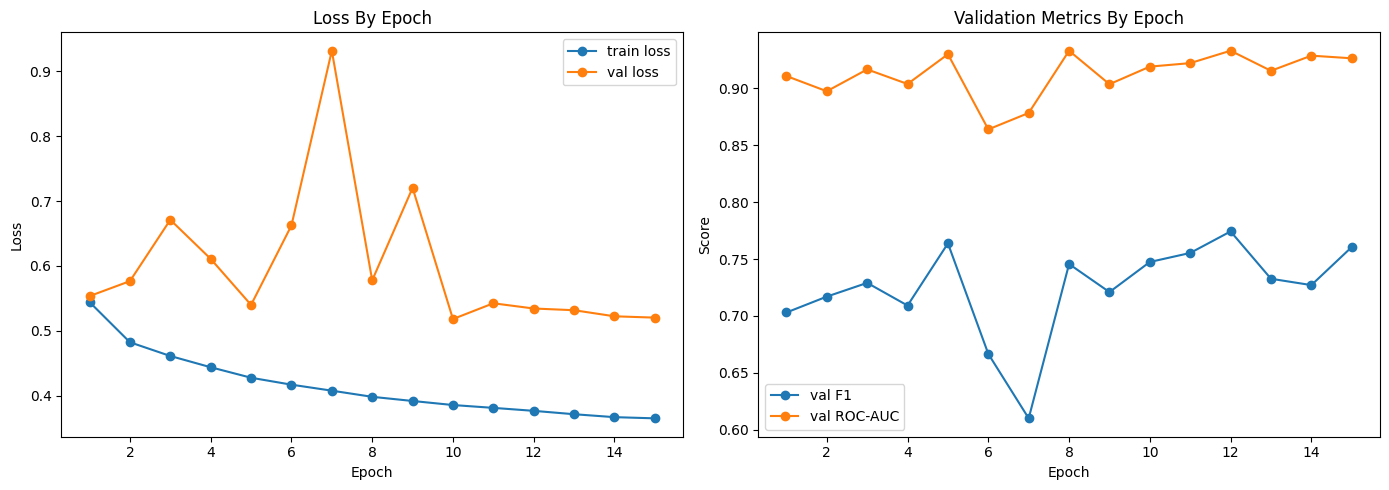

Best validation metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.534411,0.85692,0.696053,0.872255,0.774256,0.932982,10051,25051,4389,1472


Test metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.544842,0.88057,0.768887,0.834199,0.800212,0.935595,9801,26283,2946,1948


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val loss')
axes[0].set_title('Loss By Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_f1'], marker='o', label='val F1')
axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
axes[1].set_title('Validation Metrics By Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Best validation metrics:')
display(pd.DataFrame([metrics_payload['best_val_metrics']]))

print('Test metrics:')
display(pd.DataFrame([metrics_payload['test_metrics']]))


## Outputs

Saved under `PROJECT_ROOT / 'training_runs' / run_name`:

- `best_model.pt`
- `history.csv`
- `metrics.json`
- `config.json`

This notebook uses the cleaned split CSVs from `artifacts/` and does not create new splits.
